In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)



total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [ ]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:

numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("Mean of tip:", df['tip'].mean())
print("Value counts of sex:")
print(df['sex'].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: []
Mean of tip: 2.99827868852459
Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


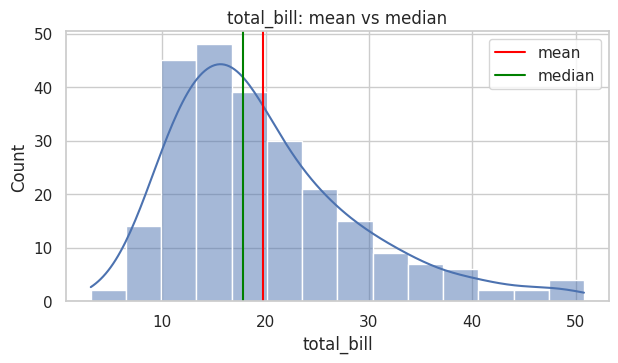

In [ ]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()


Mean: 2.99827868852459
Median: 2.9
Mode: 2.0
Is mean greater than median? True


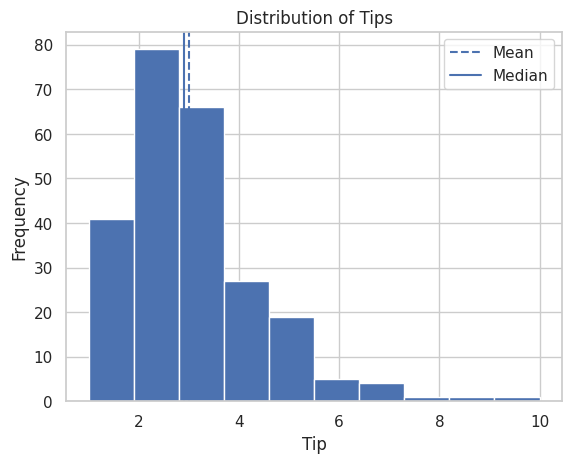

In [ ]:
tip = df['tip']
print("Mean:", tip.mean())
print("Median:", tip.median())
print("Mode:", tip.mode()[0])
print("Is mean greater than median?", tip.mean() > tip.median())
import matplotlib.pyplot as plt
plt.hist(tip, bins=10)
plt.axvline(tip.mean(), linestyle='--', label='Mean')
plt.axvline(tip.median(), linestyle='-', label='Median')
plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.title("Distribution of Tips")
plt.legend()
plt.show()

In [ ]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [ ]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [ ]:
tip = df['tip']
print("Range:", tip.max() - tip.min())
print("Variance:", tip.var())
print("Standard Deviation:", tip.std())
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


In [ ]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


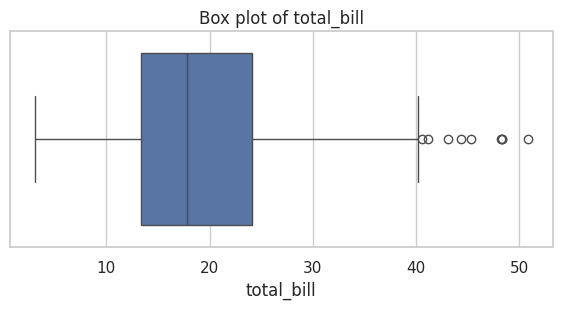

In [ ]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


In [ ]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive
